# Instacart Market Basket Analysis

### Student Name : Dikitso Motona
### Student Number : Bida24-328
### Course : Business Intelligence and Data Analytics
### Date: 03 / 03 / 2026


## **T03: Exploratory Data Analysis (Part 2)**
This notebook continues the exploration of the Instacart interim datasets.
We will build on Part 1 by analyzing additional variables, examining relationships between tables and identifying further patterns in the data.


## **Step 1: Create the Tutorial 3 Notebook**
A copy of the Tutorial 2 notebook was saved as `T03_Exploratory_Data_Analysis_Part2.ipynb` to keep the tutorials organised.

### **Step 2: Load Libraries and Interim Data**

We import the necessary Python libraries and mount Google Drive to access the datasets. Interim copies are loaded without touching raw data ensuring consistency across analyses.

In [1]:
# Step 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import os

# Mount Google Drive (Colab only)
drive.mount('/content/drive')

# Path to interim datasets
data_path = "/content/drive/MyDrive/ADA2026_Instacart_Project/Data/Interim/"

# Load interim datasets
orders = pd.read_csv(os.path.join(data_path, "orders_interim.csv"))
products = pd.read_csv(os.path.join(data_path, "products_interim.csv"))
order_products = pd.read_csv(os.path.join(data_path, "order_products_interim.csv"))

# Quick check
print("Orders shape:", orders.shape)
print("Products shape:", products.shape)
print("Order_Products shape:", order_products.shape)

Mounted at /content/drive
Orders shape: (3421083, 7)
Products shape: (49688, 4)
Order_Products shape: (32434489, 4)


### **Step 3: Confirm Table Meaning**
We inspect the first few rows of each table to understand what each row represents and identify key columns for grouping and merging.

In [2]:
# Inspect Orders table
print("Orders table sample:")
display(orders.head())

# Inspect Products table
print("Products table sample:")
display(products.head())

# Inspect Order_Products table
print("Order_Products table sample:")
display(order_products.head())

Orders table sample:


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


Products table sample:


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


Order_Products table sample:


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


- **Orders table:** Each row represents a single order placed by a user . Key columns: `order_id`, `user_id`, `order_number`, `order_dow`, `order_hour_of_day`, `days_since_prior_order`.

- **Products table:** Each row represents a single product sold on Instacart. Key columns: `product_id`, `product_name`, `aisle_id`, `department_id`.

- **Order_Products table:** Each row represents a specific product within a particular order . Key columns: `order_id`, `product_id`, `add_to_cart_order`, `reordered`.

**KEY COLUMNS FOR GROUPING AND MERGING:**
- `order_id` — links the `orders` and `order_products` tables
- `product_id` — links the `order_products` and `products` tables
- `order_dow` and `order_hour_of_day` — useful for grouping orders by time
- `reordered` — useful for grouping by customer behaviour

## **Step 4: Define Bivariate Questions**
1. How does the day of the week (`order_dow`) relate to the
   hour of the day (`order_hour_of_day`) in terms of order patterns?
2. Is there a relationship between `order_number` (order sequence) and `days_since_prior_order`?  
3. Do certain product categories (`department_id` or `aisle_id`) tend to be reordered more often (`reordered`)?

### **Step 5: Categorical vs Categorical Analysis**
We create a contingency table to examine the relationship between the day of the week (`order_dow`) and the hour of the day (`order_hour_of_day`).
This helps identify the busiest days and times for orders.

In [3]:
# Create contingency table
dow_hour_table = pd.crosstab(orders['order_dow'], orders['order_hour_of_day'])
dow_hour_table

order_hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
order_dow,,,,,,,,,,,,,,,,,,,,,
0,3936,2398,1409,963,813,1168,3329,12410,28108,40798,...,54552,53954,49463,39753,29572,22654,18277,14423,11246,6887
1,3674,1830,1105,748,809,1607,5370,16571,34116,51908,...,46764,46403,44761,36792,28977,22145,16281,11943,8992,5620
2,3059,1572,943,719,744,1399,4758,13245,24635,36314,...,37173,37469,37541,32151,26470,20084,15039,10653,8146,5358
3,2952,1495,953,654,719,1355,4562,12396,22553,32312,...,34773,35990,35273,30368,25001,19249,13795,10278,8242,5181
4,2642,1512,899,686,730,1330,4401,12493,21814,31409,...,33625,34222,34093,29378,24425,19350,14186,10796,8812,5645
5,3189,1672,1016,841,910,1574,4866,13434,24015,34232,...,37407,37508,35860,29955,24310,18741,13322,9515,7498,5265
6,3306,1919,1214,863,802,1136,3243,11319,22960,30839,...,38748,38093,35562,30398,24157,18346,13392,10501,8532,6087


##**Interpretation:**
- **Peak ordering hours:** Most orders occur between **8 AM and 3 PM** across all days.  
- **Busiest days:** Sunday (0) and Monday (1) have the highest total orders.  
- **Mid-week trends:** Tuesday–Thursday show lower order counts, gradually increasing again toward Friday and Saturday.  
- **Late night:** Orders are minimal from midnight to 6 AM on all days.
- **Peak combination:** Sunday (0) between 9 AM and 3 PM shows the highest
order counts, with values exceeding 40,000 orders in a single hour.

## **Step 6: Visualise Categorical Relationships with Heatmap**
A heatmap makes it easier to see peak ordering times by day and hour at a glance.

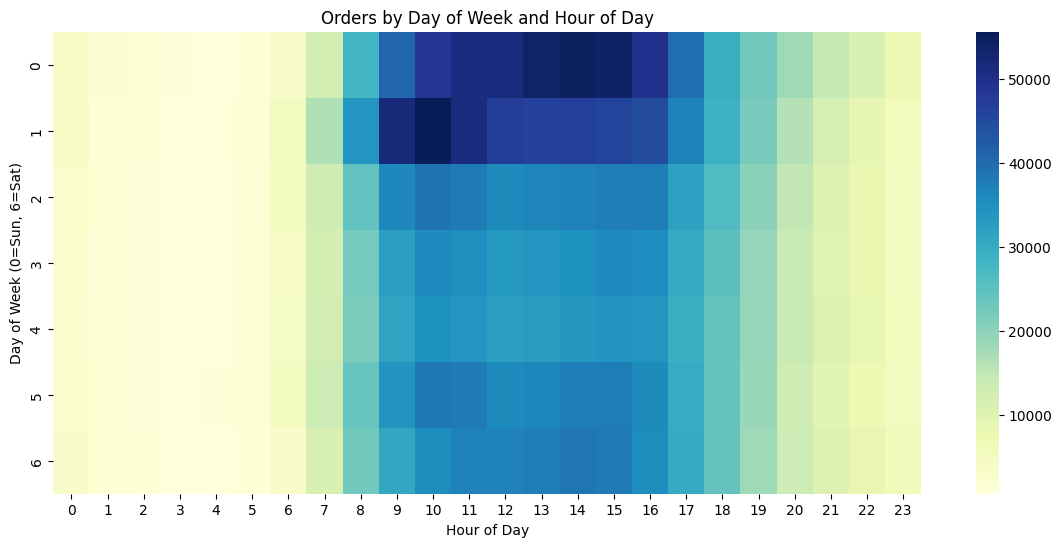

In [4]:
import seaborn as sns

# Create contingency table
ct = pd.crosstab(orders['order_dow'], orders['order_hour_of_day'])

# Plot heatmap
plt.figure(figsize=(14,6))
sns.heatmap(ct, cmap="YlGnBu", annot=False)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0=Sun, 6=Sat)")
plt.title("Orders by Day of Week and Hour of Day")

# Save the figure
plt.savefig("/content/drive/MyDrive/ADA2026_Instacart_Project/outputs/figures/orders_by_day_hour_heatmap.png", bbox_inches='tight')

# Display the plot
plt.show()




##**Interpretation:**
Orders peak on Sundays (0) and Mondays (1), mostly between 8 AM and 3 PM.
Mid-week days (Tuesday–Thursday) have lower activity and orders are minimal
during late night hours (0–6 AM). In the heatmap, dark blue represents peak
order hours while light yellow indicates low order activity.

##**Step 7: Numerical vs Categorical Analysis**
We analyze how the **days since the prior order** varies by day of the week (`order_dow`) using mean and median values.  
This helps identify which days users tend to reorder faster or slower.

In [5]:
# Mean days since prior order by day of week
mean_days = orders.groupby('order_dow')['days_since_prior_order'].mean()
print("Mean days since prior order by day of week:")
print(mean_days)

# Median days since prior order by day of week
median_days = orders.groupby('order_dow')['days_since_prior_order'].median()
print("\nMedian days since prior order by day of week:")
print(median_days)

Mean days since prior order by day of week:
order_dow
0    11.773868
1    11.311552
2    11.169766
3    10.768301
4    10.522935
5    10.508295
6    11.438924
Name: days_since_prior_order, dtype: float64

Median days since prior order by day of week:
order_dow
0    8.0
1    8.0
2    8.0
3    7.0
4    7.0
5    7.0
6    7.0
Name: days_since_prior_order, dtype: float64




##**Interpretation:**
- People take slightly longer to reorder on weekends — Sunday (0) has the
  highest mean of **11.77 days** and Saturday (6) has a mean of **11.44 days**
- Weekdays are faster — Friday (5) has the lowest mean of **10.51 days**
- The median confirms this pattern — Sunday and Monday have a median of
  **8 days** while Thursday, Friday and Saturday have a median of **7 days**
- The difference between mean and median suggests some customers wait
  much longer than average, pulling the mean higher

## **Step 8: Visual Comparison Using Boxplots**
We use a boxplot to compare the distribution of **days since prior order** (`days_since_prior_order`) across each day of the week (`order_dow`). This helps visualize variability , outliers and typical reorder intervals.

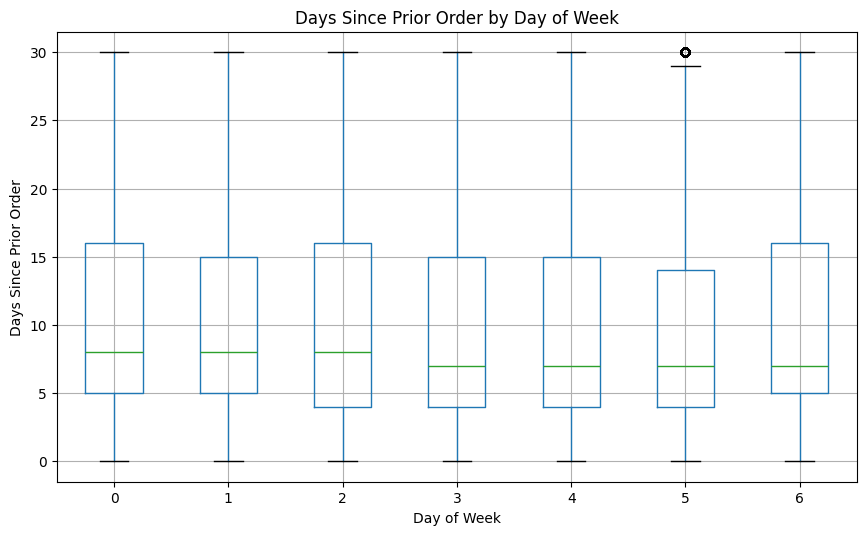

In [6]:
# Boxplot of days since prior order by day of week
orders.boxplot(column='days_since_prior_order', by='order_dow', figsize=(10,6))
plt.xlabel("Day of Week")
plt.ylabel("Days Since Prior Order")
plt.title("Days Since Prior Order by Day of Week")
plt.suptitle("")  # remove automatic 'Boxplot grouped by ...' title

# Save the figure
plt.savefig("/content/drive/MyDrive/ADA2026_Instacart_Project/outputs/figures/days_since_prior_boxplot.png", bbox_inches='tight')

# Display the plot
plt.show()

##**Interpretation:**  
- People take a slightly **longer time to reorder on weekends** (Sundays 0 and Saturdays 6).  
- Weekdays (Monday 1 to Friday 5) have shorter reorder times, with **Friday (5) showing a smaller spread in reorder days** — most users reorder around the same interval.  
- Most users reorder around **7–8 days**, but some wait much longer — these appear as outliers above the whiskers.

## **Step 9: Numerical vs Numerical Analysis**
We use a scatter plot to examine the relationship between **order sequence (`order_number`)** and **time between orders (`days_since_prior_order`)**.  
This helps identify patterns in how reorder intervals change as users place more orders.

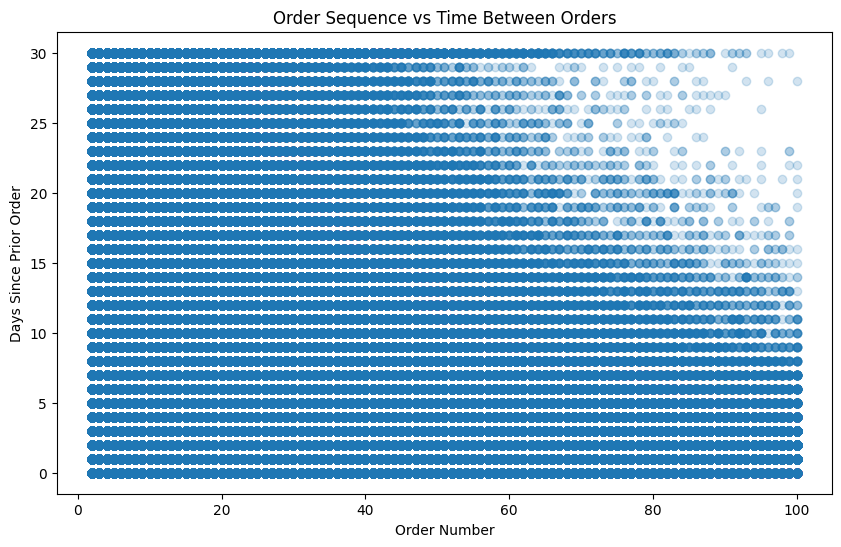

In [7]:
# Prepare data
tmp = orders[['order_number', 'days_since_prior_order']].dropna()

# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(tmp['order_number'], tmp['days_since_prior_order'], alpha=0.2, color='#1f77b4')
plt.xlabel("Order Number")
plt.ylabel("Days Since Prior Order")
plt.title("Order Sequence vs Time Between Orders")

# Save the figure
plt.savefig("/content/drive/MyDrive/ADA2026_Instacart_Project/outputs/figures/order_vs_days_scatter.png", bbox_inches='tight')

# Display the plot
plt.show()

**Interpretation:**
- The scatter plot shows that `days_since_prior_order` values are
  **spread across all order numbers (1–100)**, with no strong upward
  or downward trend — meaning reorder intervals do not change
  significantly as customers place more orders
- The plot is **densely packed on the left side (order numbers 1–60)**
  and becomes increasingly sparse beyond order 60, confirming that
  most customers have fewer total orders
- The **horizontal bands** visible across the plot suggest that certain
  reorder intervals (like 7, 14, 21, 30 days) are far more common than
  others — indicating weekly and monthly shopping patterns
- The **top band at 30 days** is notably dense across all order numbers,
  reflecting the 30-day cap in the dataset
- **No clear correlation** exists between order sequence and reorder
  interval — loyal customers (high order numbers) reorder at similar
  intervals to newer customers


## **Step 10: Correlation**
We compute the **correlation** between numerical variables (`order_number` and `days_since_prior_order`) to see if there’s any linear relationship.
Correlation values range from **-1 to 1**, where 0 means no linear rationship.

In [8]:
# Compute correlation
corr = tmp.corr()
print("Correlation matrix:")
print(corr)

Correlation matrix:
                        order_number  days_since_prior_order
order_number                1.000000               -0.360564
days_since_prior_order     -0.360564                1.000000


##**Interpretation:**  

- The correlation between `order_number` and `days_since_prior_order`
  is **-0.36**, indicating a **weak to moderate negative relationship**
- This means that as customers place more orders (higher order number),
  they tend to wait **slightly fewer days** before reordering
- However at **-0.36** the relationship is not strong enough to be
  conclusive — other factors likely influence reorder timing
- This is consistent with what we saw in the scatter plot — no strong
  trend but a slight tendency for loyal customers to reorder more frequently

## **Step 11: Reorder Behaviour Analysis**
We analyze the **average reorder rate** by day of the week (`order_dow`) to see on which days users are more likely to reorder products.

In [9]:
# Merge orders and reordered info
merged = orders.merge(
    order_products[['order_id', 'reordered']],
    on='order_id',
    how='inner'
)

# Compute average reorder rate by day of week
reorder_rate = merged.groupby('order_dow')['reordered'].mean()
print("Average reorder rate by day of week:")
print(reorder_rate)

Average reorder rate by day of week:
order_dow
0    0.585276
1    0.603843
2    0.589771
3    0.586272
4    0.590979
5    0.595470
6    0.574369
Name: reordered, dtype: float64



##**Interpretation:**
- **Monday (1)** has the highest reorder rate at **0.604**, meaning
  approximately 60% of products ordered on Mondays are reorders
- **Saturday (6)** has the lowest reorder rate at **0.574**, suggesting
  customers are slightly more likely to try new products on weekends
- **Sunday (0)** also has a relatively lower reorder rate at **0.585**
  compared to weekdays
- Overall the reorder rate is **fairly consistent across the week**
  (ranging from 0.574 to 0.604), showing that customers regularly
  purchase familiar products regardless of the day
- The narrow range of values suggests that **day of the week has only
  a minor influence** on reorder behaviour

## **Step 12: Save Key Figures**

All important visualisations were saved to the **outputs/figures/** directory using `plt.savefig()` before displaying the plots . The saved figures include the heatmap, boxplot, and scatter plot, which confirms that the key analysis visuals are stored for reporting and assessment.

In [10]:
import os

figures_path = "/content/drive/MyDrive/ADA2026_Instacart_Project/outputs/figures/"
print("Saved figures:")
print(os.listdir(figures_path))

Saved figures:
['orders_by_day.png', 'orders_by_day_hour_heatmap.png', 'days_since_prior_boxplot.png', 'order_vs_days_scatter.png']


**Confirming Saved Figures**

The code `os.listdir("../outputs/figures/")` was used to check the **outputs/figures/** folder and confirm that the visualisations were successfully saved. The output displayed the filenames of the saved figures.

### **Interpretation Summary**

**Strongest Relationships Observed**  
The analysis shows that order activity varies across different days and hours. Certain hours of the day have noticeably higher order volumes, indicating peak shopping periods. The analysis also shows that customers tend to place new orders about once a week, based on the average and median values of days since the prior order. Reorder behaviour is also fairly consistent across the week, with similar reorder rates on most days.

**Key Insights**  
Customers tend to shop more during specific hours of the day, suggesting clear peak periods for ordering. The typical time between orders is around one week, meaning many customers follow a regular purchasing pattern. Reorder rates remain relatively stable throughout the week, showing that repeat purchasing behaviour is common.

**Limitations of EDA**  
Exploratory Data Analysis mainly identifies patterns and relationships in the data but does not explain why they occur. Some factors influencing customer behaviour, such as promotions or product types, are not included in this analysis.

**Questions for Further Testing**  
Further analysis could investigate whether certain product categories are reordered more often than others. Another useful question would be whether customers who place orders more frequently also have higher reorder rates.